In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import VotingClassifier

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss, zero_one_loss
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import balanced_accuracy_score

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

In [29]:
path_train = 'train_k.csv'
train = pd.read_csv(path_train)
train.head()

,cat_bin,period_enc,place_enc,size_1,size_2,size_3,weight,target
0,0.0,2,1,43.3,14.0,208.0,4575.0,1
1,1.0,0,0,39.1,18.7,181.0,3750.0,0
2,0.0,1,1,42.6,13.7,213.0,4950.0,1
3,1.0,0,1,46.8,15.4,215.0,5150.0,1
4,0.0,1,0,39.6,17.2,196.0,3550.0,0


In [30]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   cat_bin     233 non-null    float64
 1   period_enc  239 non-null    int64  
 2   place_enc   239 non-null    int64  
 3   size_1      239 non-null    float64
 4   size_2      239 non-null    float64
 5   size_3      239 non-null    float64
 6   weight      239 non-null    float64
 7   target      239 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 15.1 KB


In [31]:
train.describe()

,cat_bin,period_enc,place_enc,size_1,size_2,size_3,weight,target
count,233.000000,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000
mean,0.515021,1.037657,1.230126,43.963598,17.153975,201.037657,4210.355649,0.753138
std,0.500850,0.826710,0.693133,5.567935,1.966071,14.245250,820.374722,0.762667
min,0.000000,0.000000,0.000000,32.100000,13.100000,172.000000,2700.000000,0.000000
25%,0.000000,0.000000,1.000000,39.200000,15.700000,190.000000,3550.000000,0.000000
50%,1.000000,1.000000,1.000000,43.800000,17.300000,197.000000,4050.000000,1.000000
75%,1.000000,2.000000,2.000000,49.100000,18.600000,214.000000,4762.500000,1.000000
max,1.000000,2.000000,2.000000,59.600000,21.500000,231.000000,6300.000000,2.000000


In [32]:
train.isnull().sum()

,0
cat_bin,6
period_enc,0
place_enc,0
size_1,0
size_2,0
size_3,0
weight,0
target,0


In [33]:
len(train) - len(train.drop_duplicates())

0

In [34]:
train = train.drop_duplicates()
train.shape

(239, 8)

In [35]:
train['cat_bin'] = train['cat_bin'].fillna(train['cat_bin'].mode()[0])

In [36]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   cat_bin     239 non-null    float64
 1   period_enc  239 non-null    int64  
 2   place_enc   239 non-null    int64  
 3   size_1      239 non-null    float64
 4   size_2      239 non-null    float64
 5   size_3      239 non-null    float64
 6   weight      239 non-null    float64
 7   target      239 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 15.1 KB


In [37]:
train.describe()

,cat_bin,period_enc,place_enc,size_1,size_2,size_3,weight,target
count,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000
mean,0.527197,1.037657,1.230126,43.963598,17.153975,201.037657,4210.355649,0.753138
std,0.500308,0.826710,0.693133,5.567935,1.966071,14.245250,820.374722,0.762667
min,0.000000,0.000000,0.000000,32.100000,13.100000,172.000000,2700.000000,0.000000
25%,0.000000,0.000000,1.000000,39.200000,15.700000,190.000000,3550.000000,0.000000
50%,1.000000,1.000000,1.000000,43.800000,17.300000,197.000000,4050.000000,1.000000
75%,1.000000,2.000000,2.000000,49.100000,18.600000,214.000000,4762.500000,1.000000
max,1.000000,2.000000,2.000000,59.600000,21.500000,231.000000,6300.000000,2.000000


In [38]:
train.isnull().sum()

,0
cat_bin,0
period_enc,0
place_enc,0
size_1,0
size_2,0
size_3,0
weight,0
target,0


In [39]:
data = train.drop(columns = ['target'])
target = np.array(train['target'])

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size = 0.2, random_state = 42, stratify = target)

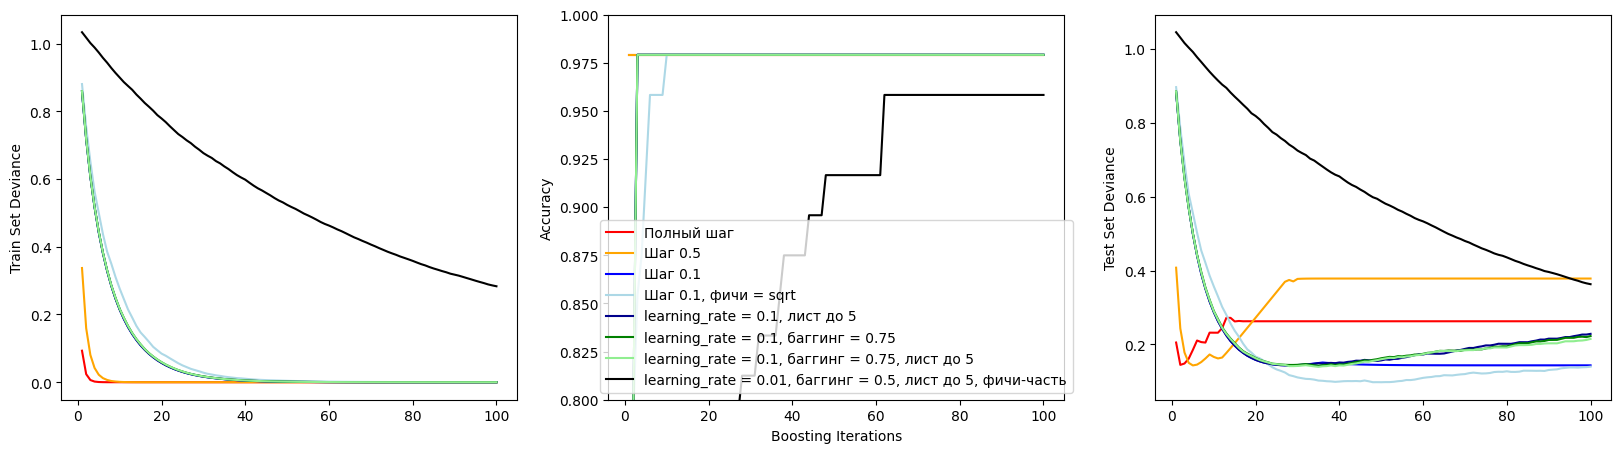

In [40]:
labels, y = np.unique(target, return_inverse = True)

original_params = {'n_estimators' : 100,
                   'random_state' : 42
                  }

fig = plt.figure(figsize = (20, 5))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

for label, color, setting in [('Полный шаг', 'red', {'learning_rate' : 1.0, 'subsample' : 1.0}),
                              ('Шаг 0.5', 'orange', {'learning_rate' : 0.5, 'subsample' : 1.0}),
                              ('Шаг 0.1', 'blue', {'learning_rate' : 0.1, 'subsample' : 1.0}),
                              ('Шаг 0.1, фичи = sqrt', 'lightblue',
                               {'learning_rate' : 0.1, 'subsample' : 1.0, 'max_features' : 'sqrt'}),
                              ('learning_rate = 0.1, лист до 5', 'darkblue',
                               {'learning_rate' : 0.1, 'subsample' : 1.0, 'min_samples_split' : 5}),
                              ('learning_rate = 0.1, баггинг = 0.75', 'green',
                               {'learning_rate' : 0.1, 'subsample' : 0.75}),
                              ('learning_rate = 0.1, баггинг = 0.75, лист до 5', 'lightgreen',
                               {'learning_rate' : 0.1, 'subsample' : 0.75, 'min_samples_split' : 5}),
                              ('learning_rate = 0.01, баггинг = 0.5, лист до 5, фичи-часть', 'black',
                               {'learning_rate' : 0.01, 'subsample' : 0.5, 'min_samples_split' : 5, 'max_features' : 'sqrt'})
                             ]:

    params = dict(original_params)
    params.update(setting)

    clf = GradientBoostingClassifier(**params)
    clf.fit(X_train, y_train)

    train_deviance = np.zeros((params['n_estimators']), dtype = np.float64)
    for i, y_pred in enumerate(clf.staged_predict_proba(X_train)):
        train_deviance[i] = log_loss(y_train, y_pred)

    ax1.plot((np.arange(train_deviance.shape[0]) + 1),
             train_deviance,
             '-',
             color = color,
             label = label
            )

    test_score = np.zeros((params['n_estimators']), dtype = np.float64)
    for i, y_pred in enumerate(clf.staged_predict(X_test)):
        test_score[i] = accuracy_score(y_test, y_pred)

    ax2.plot((np.arange(test_score.shape[0]) + 1),
             test_score,
             '-',
             color = color,
             label = label
            )

    test_deviance = np.zeros((params['n_estimators']), dtype = np.float64)
    for i, y_pred in enumerate(clf.staged_predict_proba(X_test)):
        test_deviance[i] = log_loss(y_test, y_pred)

    ax3.plot((np.arange(test_deviance.shape[0]) + 1),
             test_deviance,
             '-',
             color = color,
             label = label
            )

ax2.legend(loc = 'lower center')
ax2.set_xlabel('Boosting Iterations')
ax2.set_ylim(0.8, 1.0)
ax1.set_ylabel('Train Set Deviance')
ax2.set_ylabel('Accuracy')
ax3.set_ylabel('Test Set Deviance')

plt.show()

In [41]:
gb = GradientBoostingClassifier(learning_rate = 0.1,
                                n_estimators = 40,
                                subsample = 1.0,
                                max_features = 'sqrt',
                                #min_samples_split = 5,
                                random_state = 42
                               )

gb.fit(X_train, y_train)

GradientBoostingClassifier(max_features='sqrt', n_estimators=40,
                           random_state=42)

Правильность на обучающем наборе: 1.000
Правильность на тестовом наборе: 0.979
Accuracy на обучающем наборе: 1.000
Accuracy на тестовом наборе: 0.979
Cross validation score: 0.996
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        22
           1       1.00      1.00      1.00        17
           2       0.90      1.00      0.95         9

    accuracy                           0.98        48
   macro avg       0.97      0.98      0.97        48
weighted avg       0.98      0.98      0.98        48



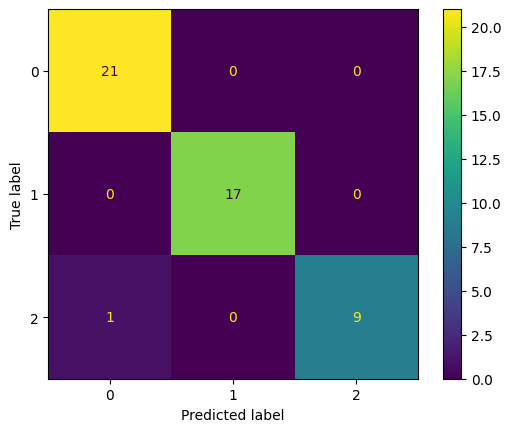

In [42]:
print("Правильность на обучающем наборе: {:.3f}".format(gb.score(X_train, y_train)))
print("Правильность на тестовом наборе: {:.3f}".format(gb.score(X_test, y_test)))

y_pred_gb_train = gb.predict(X_train)
y_pred_gb_test = gb.predict(X_test)

print("Accuracy на обучающем наборе: {:.3f}".format(accuracy_score(y_pred_gb_train, y_train)))
print("Accuracy на тестовом наборе: {:.3f}".format(accuracy_score(y_pred_gb_test, y_test)))
print("Cross validation score: {:.3f}".format(np.mean(cross_val_score(gb, data, target, cv = 10, scoring = 'accuracy'))))

print(classification_report(y_pred_gb_test, y_test))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_gb_test)).plot();

In [43]:
num_features = ['size_1', 'size_2', 'size_3', 'weight']
passthrough_features = ['cat_bin', 'period_enc', 'place_enc']

In [44]:
num = Pipeline(steps = [('scaler', StandardScaler())])

CT_knn = ColumnTransformer(transformers = [('num', num, num_features),
                                           ('passthrough', 'passthrough', passthrough_features)]).set_output(transform = 'pandas')

display(CT_knn)
ct_knn = CT_knn.fit_transform(X_train)
pd.DataFrame(ct_knn).head()

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['size_1', 'size_2', 'size_3', 'weight']),
                                ('passthrough', 'passthrough',
                                 ['cat_bin', 'period_enc', 'place_enc'])])

,num__size_1,num__size_2,num__size_3,num__weight,passthrough__cat_bin,passthrough__period_enc,passthrough__place_enc
190,0.573035,-1.748434,0.910745,0.841282,0.0,2,1
86,-0.215533,0.654811,-0.424107,0.028678,1.0,1,0
194,0.357971,0.855081,-0.424107,-0.091707,0.0,0,2
77,-0.806959,0.104067,-1.056405,-0.513057,0.0,0,0
164,0.985241,-0.496744,1.964575,1.894656,1.0,1,1


In [45]:
pipe_knn = Pipeline([('preproc', CT_knn),
                     ('classifier', KNeighborsClassifier())])

pipe_knn.fit(X_train, y_train)

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['size_1', 'size_2', 'size_3',
                                                   'weight']),
                                                 ('passthrough', 'passthrough',
                                                  ['cat_bin', 'period_enc',
                                                   'place_enc'])])),
                ('classifier', KNeighborsClassifier())])

In [46]:
n_neighbors = np.arange(1, 6)

param_grid_knn = [{'preproc__num__scaler' : [StandardScaler(), RobustScaler(), MinMaxScaler()],
                   'classifier' : [KNeighborsClassifier()],
                   'classifier__n_neighbors': n_neighbors,
                   'classifier__weights': ['uniform', 'distance'],
                   'classifier__metric': ['euclidean', 'manhattan'],
                   'classifier__p': [1, 2, 3]
                  }]

grid_knn = GridSearchCV(pipe_knn,
                        param_grid = param_grid_knn,
                        scoring = 'accuracy',
                        n_jobs = -1,
                        cv = 10,
                        return_train_score = True)

grid_knn.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preproc',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['size_1',
                                                                          'size_2',
                                                                          'size_3',
                                                                          'weight']),
                                                                        ('passthrough',
                                                                         'passthrough',
                                                                         ['cat_bin',
                                                                          'period_enc',
                                                                          'place_enc'])])),
                                       ('classifier', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid=[{'classifier': [KNeighborsClassifier()],
                          'classifier__metric': ['euclidean', 'manhattan'],
                          'classifier__n_neighbors': array([1, 2, 3, 4, 5]),
                          'classifier__p': [1, 2, 3],
                          'classifier__weights': ['uniform', 'distance'],
                          'preproc__num__scaler': [StandardScaler(),
                                                   RobustScaler(),
                                                   MinMaxScaler()]}],
             return_train_score=True, scoring='accuracy')

In [47]:
# grid_knn_result = pd.DataFrame(grid_knn.cv_results_).sort_values(['rank_test_score','std_test_score']).T
# display(grid_knn_result, grid_knn.best_params_)

Правильность на обучающем наборе: 1.000
Правильность на тестовом наборе: 0.958
Accuracy на обучающем наборе: 1.000
Accuracy на тестовом наборе: 0.958
Cross validation score: 0.988
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        19
           1       1.00      1.00      1.00        17
           2       1.00      0.83      0.91        12

    accuracy                           0.96        48
   macro avg       0.97      0.94      0.95        48
weighted avg       0.96      0.96      0.96        48



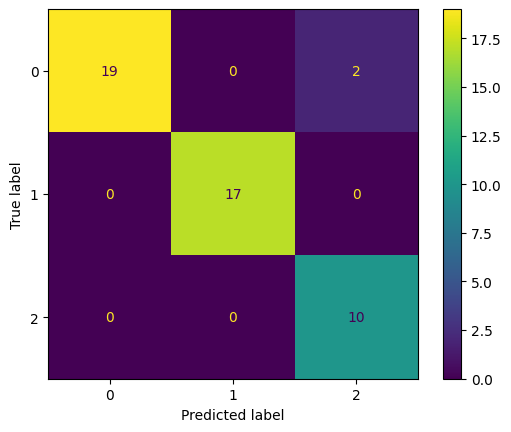

In [48]:
knn_best = Pipeline([('preproc', CT_knn),
                     ('classifier', KNeighborsClassifier(n_neighbors = 1,
                                                         weights = 'uniform',
                                                         metric = 'euclidean',
                                                         p = 1))])


knn_best.fit(X_train, y_train)

print("Правильность на обучающем наборе: {:.3f}".format(knn_best.score(X_train, y_train)))
print("Правильность на тестовом наборе: {:.3f}".format(knn_best.score(X_test, y_test)))

y_pred_knn_best_train = knn_best.predict(X_train)
y_pred_knn_best_test = knn_best.predict(X_test)

print("Accuracy на обучающем наборе: {:.3f}".format(accuracy_score(y_pred_knn_best_train, y_train)))
print("Accuracy на тестовом наборе: {:.3f}".format(accuracy_score(y_pred_knn_best_test, y_test)))
print("Cross validation score: {:.3f}".format(np.mean(cross_val_score(knn_best, data, target, cv = 10, scoring = 'accuracy'))))

print(classification_report(y_pred_knn_best_test, y_test))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn_best_test)).plot();

In [49]:
num = Pipeline(steps = [('scaler', StandardScaler())])

CT_logreg = ColumnTransformer(transformers = [('num', num, num_features),
                                              ('passthrough', 'passthrough', passthrough_features)]).set_output(transform = 'pandas')

display(CT_logreg)
ct_logreg = CT_logreg.fit_transform(X_train)
pd.DataFrame(ct_logreg).head()

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['size_1', 'size_2', 'size_3', 'weight']),
                                ('passthrough', 'passthrough',
                                 ['cat_bin', 'period_enc', 'place_enc'])])

,num__size_1,num__size_2,num__size_3,num__weight,passthrough__cat_bin,passthrough__period_enc,passthrough__place_enc
190,0.573035,-1.748434,0.910745,0.841282,0.0,2,1
86,-0.215533,0.654811,-0.424107,0.028678,1.0,1,0
194,0.357971,0.855081,-0.424107,-0.091707,0.0,0,2
77,-0.806959,0.104067,-1.056405,-0.513057,0.0,0,0
164,0.985241,-0.496744,1.964575,1.894656,1.0,1,1


In [50]:
pipe_logreg = Pipeline([('preproc', CT_logreg),
                        ('classifier', LogisticRegression(max_iter = 1000))])

pipe_logreg.fit(X_train, y_train)

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['size_1', 'size_2', 'size_3',
                                                   'weight']),
                                                 ('passthrough', 'passthrough',
                                                  ['cat_bin', 'period_enc',
                                                   'place_enc'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [51]:
C = [100, 10, 1.0, 0.1, 0.01]

param_grid_logreg = [{'preproc__num__scaler' : [StandardScaler(), RobustScaler(), MinMaxScaler()],
                      'classifier' : [LogisticRegression(max_iter = 1000)],
                      'classifier__penalty': ['l1'],
                      #'classifier__penalty': ['l2'],
                      'classifier__C': C,
                      'classifier__solver' : ['liblinear', 'saga'],
                      #'classifier__solver' : ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
                      }]

grid_logreg = GridSearchCV(pipe_logreg,
                           param_grid = param_grid_logreg,
                           scoring = 'accuracy',
                           n_jobs = -1,
                           cv = 10,
                           return_train_score = True)

grid_logreg.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preproc',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['size_1',
                                                                          'size_2',
                                                                          'size_3',
                                                                          'weight']),
                                                                        ('passthrough',
                                                                         'passthrough',
                                                                         ['cat_bin',
                                                                          'period_enc',
                                                                          'place_enc'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid=[{'classifier': [LogisticRegression(max_iter=1000)],
                          'classifier__C': [100, 10, 1.0, 0.1, 0.01],
                          'classifier__penalty': ['l1'],
                          'classifier__solver': ['liblinear', 'saga'],
                          'preproc__num__scaler': [StandardScaler(),
                                                   RobustScaler(),
                                                   MinMaxScaler()]}],
             return_train_score=True, scoring='accuracy')

In [52]:
# grid_logreg_result = pd.DataFrame(grid_logreg.cv_results_).sort_values(['rank_test_score','std_test_score']).T
# display(grid_logreg_result, grid_logreg.best_params_)

Правильность на обучающем наборе: 1.000
Правильность на тестовом наборе: 0.979
Accuracy на обучающем наборе: 1.000
Accuracy на тестовом наборе: 0.979
Cross validation score: 0.992
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      1.00      1.00        17
           2       1.00      0.91      0.95        11

    accuracy                           0.98        48
   macro avg       0.98      0.97      0.98        48
weighted avg       0.98      0.98      0.98        48



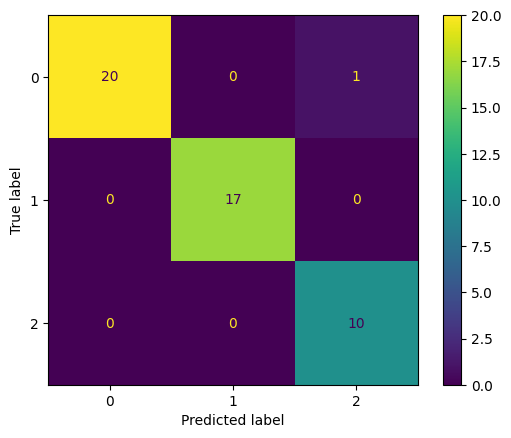

In [53]:
logreg_best = Pipeline([('preproc', CT_logreg),
                     ('classifier', LogisticRegression(penalty = 'l1',
                                                       C = 100,
                                                       solver = 'liblinear',
                                                       max_iter = 1000))])

logreg_best.fit(X_train, y_train)

print("Правильность на обучающем наборе: {:.3f}".format(logreg_best.score(X_train, y_train)))
print("Правильность на тестовом наборе: {:.3f}".format(logreg_best.score(X_test, y_test)))

y_pred_logreg_best_train = logreg_best.predict(X_train)
y_pred_logreg_best_test = logreg_best.predict(X_test)

print("Accuracy на обучающем наборе: {:.3f}".format(accuracy_score(y_pred_logreg_best_train, y_train)))
print("Accuracy на тестовом наборе: {:.3f}".format(accuracy_score(y_pred_logreg_best_test, y_test)))
print("Cross validation score: {:.3f}".format(np.mean(cross_val_score(logreg_best, data, target, cv = 10, scoring = 'accuracy'))))

print(classification_report(y_pred_logreg_best_test, y_test))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_logreg_best_test)).plot();

Правильность на обучающем наборе: 1.000
Правильность на тестовом наборе: 1.000
Accuracy на обучающем наборе: 1.000
Accuracy на тестовом наборе: 1.000
Cross validation score: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        17
           2       1.00      1.00      1.00        10

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



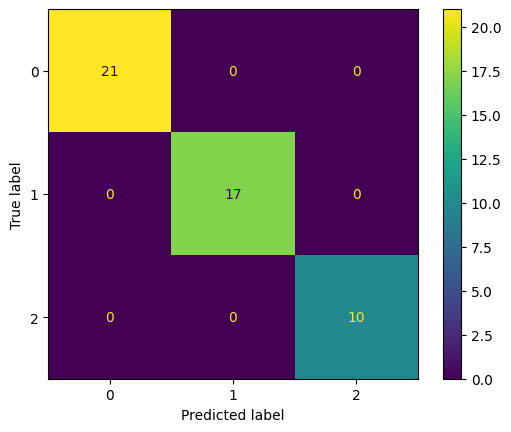

In [54]:
voting = VotingClassifier(estimators = [('gb', gb),
                                        ('knn', knn_best),
                                        ('lr', logreg_best)],
                          #voting = 'hard',
                          voting = 'soft',
                          weights = [2, 1, 2]
                         )

voting.fit(X_train, y_train)

print("Правильность на обучающем наборе: {:.3f}".format(voting.score(X_train, y_train)))
print("Правильность на тестовом наборе: {:.3f}".format(voting.score(X_test, y_test)))

y_pred_voting_train = voting.predict(X_train)
y_pred_voting_test = voting.predict(X_test)

print("Accuracy на обучающем наборе: {:.3f}".format(accuracy_score(y_pred_voting_train, y_train)))
print("Accuracy на тестовом наборе: {:.3f}".format(accuracy_score(y_pred_voting_test, y_test)))
print("Cross validation score: {:.3f}".format(np.mean(cross_val_score(voting, data, target, cv = 10, scoring = 'accuracy'))))

print(classification_report(y_pred_voting_test, y_test))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_voting_test)).plot();